# Regression Models Using Gradient Descent

## Goals

In this Assignment:

 - You will implement Linear, Quadratic and Cubic Regression models using **Gradient Descent** instead of solving simultaneous equations / normal equation.
 - You will implement Gradient Descent from scratch (no sklearn) using NumPy, in a vectorized way (no for-loop over training examples — a for-loop over iterations/epochs is fine, since Gradient Descent is inherently iterative).

## Tools
In this lab we will make use of:
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data
- Pandas, a Python library for data analysis

### Import Libraries

![Libraries](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Libraries.png?raw=true)


In [140]:
#Your code Here
#import the necessary libraries (numpy, pandas, matplotlib.pyplot)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###  Fetch Data From CSV Files

![Load Data](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Load%20N%20show.png?raw=true)

In [141]:
#Your code Here
#Read the training and testing data from the file
train_data = pd.read_csv('trainRegression.csv')
test_data = pd.read_csv('testRegression.csv')

### Show Data

In [142]:
#Your code Here
#Show the first 5 rows of the training data
train_data.head(5)

,X,R
0,0.01,-0.2730
1,0.02,-0.1170
2,0.03,-0.3090
3,0.04,0.0306
4,0.05,-0.0802


##### Expected Output


![Output 1](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O1.png?raw=true)


### Type Casting of Data

![TypeCasting](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Type%20Casting.png?raw=true)


In [143]:
#Your code Here
#TypeCast the data (train_x, train_y, test_x, test_y) into numpy arrays
x_train = np.array(train_data['X'])
y_train = np.array(train_data['R'])
x_test = np.array(test_data['X'])
y_test = np.array(test_data['R'])

### Plot Data

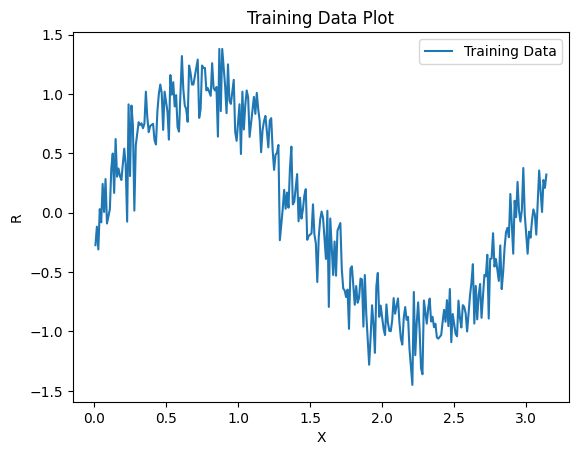

In [144]:
#Your code Here
#Plot your Training Data using matplotlib

plt.plot(x_train, y_train, label='Training Data')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Training Data Plot')
plt.legend()
plt.show()


##### Expected Output


![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O2.png?raw=true)


### Fit Linear Regression Model Using Gradient Descent (Training Data)

 As our linear Model was
 
![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

And using derivatives we transformed our model into 2 simultaneous equations

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model%20Eqs.png?raw=true)


Then converted it in matrix form

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model.png?raw=true)


NOTE: Do NOT use a for-loop to compute sums across training examples — vectorize using NumPy (matrix/dot products). A for-loop is only allowed for looping over the number of iterations/epochs.

HINT:
- Build **X** as an (m x 2) matrix: first column of ones (for θ0), second column = x
- Represent **θ** as a (2 x 1) vector: [θ0, θ1]
- Predictions: **h = X @ θ**
- Gradient: **grad = (1/m) * X.T @ (h − y)**
- Update: **θ = θ − α * grad**

In [145]:
#Your code Here
#Step 1: Build the X matrix (bias column of ones + x column)
#Step 2: Initialize theta (zeros), learning rate (alpha) and number of iterations
#Step 3: Run the Gradient Descent loop (for-loop over iterations ONLY):
#         - compute predictions h = X @ theta
#         - compute gradient = (1/m) * X.T @ (h - y)
#         - update theta = theta - alpha * gradient
#         - (optional) store the cost at every iteration in a list for plotting later

matrix_X = np.column_stack((np.ones(x_train.shape[0]), x_train)) # Build X matrix with bias term. This allows us to compute the linear regression model as a dot product between the X matrix and the theta vector.
theta = np.zeros(matrix_X.shape[1])
alpha = 0.01
num_iterations = 1000
cost_history = []

for i in range(num_iterations):
    # Compute predictions
    h = matrix_X @ theta

    # Compute cost
    cost = (1/(2 * len(y_train))) * np.sum((h - y_train) ** 2)/2
    cost_history.append(cost)

    # Compute gradient
    gradient = (1/len(y_train)) * matrix_X.T @ (h - y_train)

    # Update theta
    theta = theta - alpha * gradient



#### Plot Cost vs Iterations (Convergence Check)

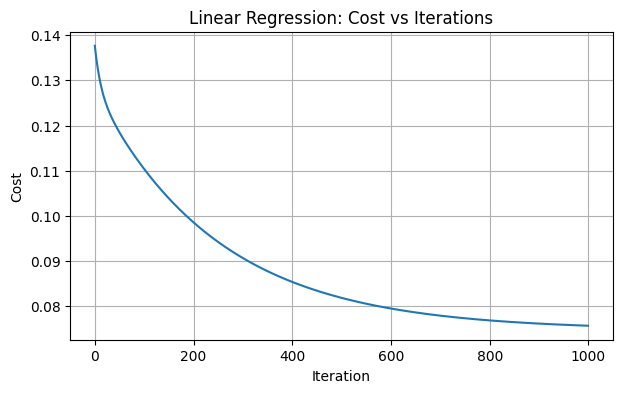

In [146]:
#Your code Here
#Plot the cost history you stored above against the iteration number
#This plot should show the cost decreasing and flattening out as Gradient Descent converges

# Plot the cost history against the iteration number
plt.figure(figsize=(7, 4))
plt.plot(range(num_iterations), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Linear Regression: Cost vs Iterations')
plt.grid(True)
plt.show()



#### Print Final Values of θ0 and θ1

In [147]:
#Your code Here
#Print the final learned values of theta (theta0, theta1)

print(f"theta0 = {theta[0]:.6f}")
print(f"theta1 = {theta[1]:.6f}")



theta0 = 0.751185
theta1 = -0.490315


### Run Predictions (Testing Data)

In [148]:
# Your code Here
# Build the test X matrix the same way (bias column of ones + test_x column)
# Use the formula: predictions = X_test @ theta
# _____DO NOT USE FOR LOOP_____

# Build the test X matrix and make predictions (vectorized)
X_test_linear = np.column_stack((np.ones(x_test.shape[0]), x_test))
y_pred_linear = X_test_linear @ theta

print("First 5 predictions:")
print(y_pred_linear[:5])


First 5 predictions:
[0.75118535 0.70215384 0.65312233 0.60409082 0.55505931]


### Mean Square Error

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

In [149]:
#Your code Here
#Using the cost function, calculate the MSE of the model on the test data

mse_linear = np.mean((y_pred_linear - y_test) ** 2)/2
print(f"Linear Regression Test MSE = {mse_linear:.6f}")

Linear Regression Test MSE = 0.157080


### Plot Data (Train and Test Data)

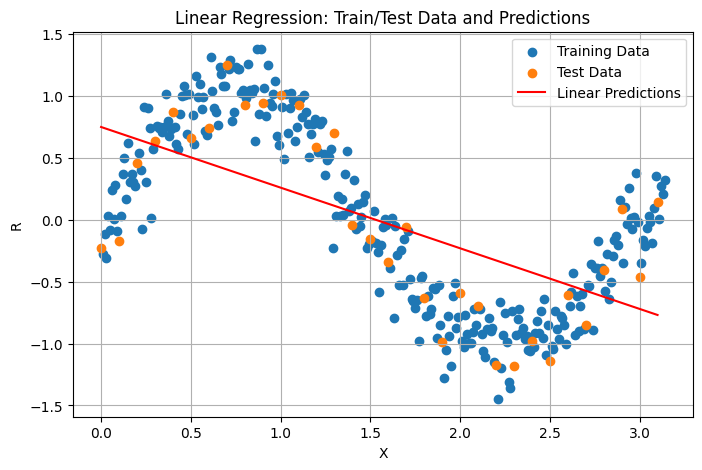

In [150]:
##Your code Here
#Plot the predicted values of y against the test_x (and overlay on training data)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, label='Training Data')
plt.scatter(x_test, y_test, label='Test Data')
plt.plot(x_test, y_pred_linear, label='Linear Predictions',color='red')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Linear Regression: Train/Test Data and Predictions')
plt.legend()
plt.grid(True)
plt.show()


## Now Fit The Quadratic Model Using Gradient Descent

Our quadratic model is:

**h(x) = θ0 + θ1 * x + θ2 * x²**

The same Gradient Descent approach applies — only the feature matrix **X** changes.

HINT:
- Build **X** as an (m x 3) matrix: [1, x, x²]
- **θ** is now a (3 x 1) vector: [θ0, θ1, θ2]
- Predictions: **h = X @ θ**
- Gradient: **grad = (1/m) * X.T @ (h − y)**
- Update: **θ = θ − α * grad** (repeat for the chosen number of iterations)

NOTE: You may need to standardize/normalize x (and x²) before running Gradient Descent so it converges — large values of x² can make Gradient Descent diverge or converge very slowly with a normal learning rate.

In [151]:
#Your code Here
#For loop is NOT recommended for computing sums across training examples,
#use numpy functions/matrix operations for that.
#A for-loop over the number of iterations IS required for Gradient Descent.
#Steps:
# 1. Build X = [1, x, x^2]  (consider normalizing x, x^2 first)
# 2. Initialize theta (zeros of shape (3,1)), alpha, iterations
# 3. Run Gradient Descent loop, storing cost history

# Build the quadratic feature matrix.
# Standardize x first so x and x^2 are on a numerically convenient scale.
quad_mean = np.mean(x_train)
quad_std = np.std(x_train)
x_train_quad = (x_train - quad_mean) / quad_std

X_quad = np.column_stack((
    np.ones(x_train.shape[0]),
    x_train_quad,
    x_train_quad ** 2
))

theta_quad = np.zeros(X_quad.shape[1])
alpha_quad = 0.01
num_iterations_quad = 5000
cost_history_quad = []

m = len(y_train)

for i in range(num_iterations_quad):
    h = X_quad @ theta_quad
    error = h - y_train
    cost = (1 / (2 * m)) * np.sum(error ** 2)/2
    cost_history_quad.append(cost)

    gradient = (1 / m) * (X_quad.T @ error)
    theta_quad = theta_quad - alpha_quad * gradient



#### Plot Cost vs Iterations (Convergence Check)

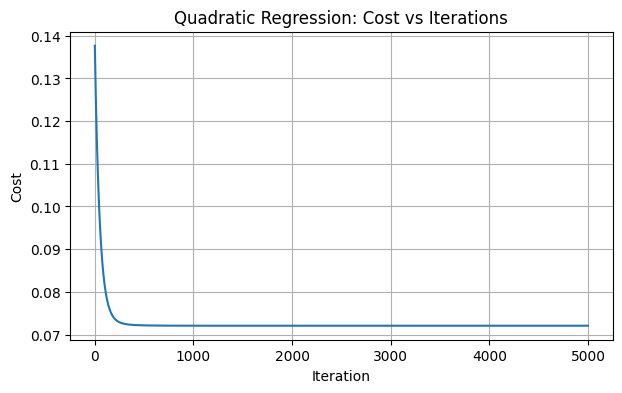

In [152]:
#Your code Here
#Plot the cost history against iteration number

plt.figure(figsize=(7, 4))
plt.plot(range(num_iterations_quad), cost_history_quad)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Quadratic Regression: Cost vs Iterations')
plt.grid(True)
plt.show()


#### Print Final Values of θ0, θ1 and θ2

In [153]:
#Your code Here
#Print the final learned values of theta

print(f"theta0 = {theta_quad[0]:.6f}")
print(f"theta1 = {theta_quad[1]:.6f}")
print(f"theta2 = {theta_quad[2]:.6f}")

theta0 = -0.111295
theta1 = -0.501544
theta2 = 0.116210


### Run Predictions (Testing data)

In [154]:
# Your code Here
# Build the test X matrix the same way [1, test_x, test_x^2] (apply the SAME normalization used on training data)
# predictions = X_test @ theta
# _____DO NOT USE FOR LOOP_____

# Build the test feature matrix using the SAME normalization as training
x_test_quad = (x_test - quad_mean) / quad_std
X_test_quad = np.column_stack((
    np.ones(x_test.shape[0]),
    x_test_quad,
    x_test_quad ** 2
))

y_pred_quad = X_test_quad @ theta_quad
print("First 5 quadratic predictions:")
print(y_pred_quad[:5])

First 5 quadratic predictions:
[1.10611453 1.00791839 0.91254317 0.81998886 0.73025548]


### Mean Square Error

In [155]:
#Your code Here
#Using the cost function calculate the MSE of the model

# Calculate the quadratic model MSE on the test data
mse_quad = np.mean((y_pred_quad - y_test) ** 2)/2
print(f"Quadratic Regression Test MSE = {mse_quad:.6f}")



Quadratic Regression Test MSE = 0.163021


### Plot Data (Train and Test Data)

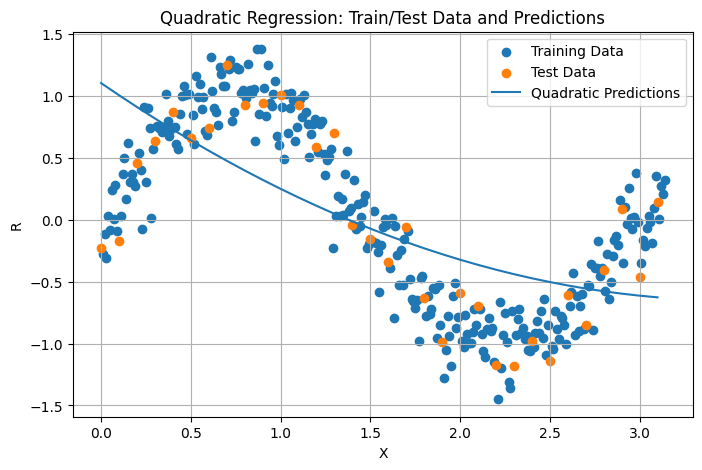

In [156]:
##Your code Here
#Plot the predicted values of y against the test_x

# Plot training data, test data, and quadratic predictions
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, label='Training Data')
plt.scatter(x_test, y_test, label='Test Data')
order = np.argsort(x_test)
plt.plot(x_test[order], y_pred_quad[order], label='Quadratic Predictions')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Quadratic Regression: Train/Test Data and Predictions')
plt.legend()
plt.grid(True)
plt.show()


## Now Fit The Cubic Model Using Gradient Descent

**h(x) = θ0 + θ1 * x + θ2 * x² + θ3 * x³**

NOTE: Same as before — you are required to compute everything without a for-loop over training data (only the iteration loop for Gradient Descent is allowed).
- HINT: Build X = [1, x, x², x³] (normalize each polynomial feature column before running Gradient Descent)

In [157]:
#Your code Here
#Build X = [1, x, x^2, x^3] (normalize features), initialize theta (zeros of shape (4,1)),
#choose alpha and iterations, then run the Gradient Descent loop storing cost history.

# Build the cubic feature matrix using the standardized x values
cubic_mean = np.mean(x_train)
cubic_std = np.std(x_train)
x_train_cubic = (x_train - cubic_mean) / cubic_std

X_cubic = np.column_stack((
    np.ones(x_train.shape[0]),
    x_train_cubic,
    x_train_cubic ** 2,
    x_train_cubic ** 3
))

theta_cubic = np.zeros(X_cubic.shape[1])
alpha_cubic = 0.005
num_iterations_cubic = 10000
cost_history_cubic = []

m = len(y_train)

for i in range(num_iterations_cubic):
    h = X_cubic @ theta_cubic
    error = h - y_train
    cost = (1 / (2 * m)) * np.sum(error ** 2)/2
    cost_history_cubic.append(cost)

    gradient = (1 / m) * (X_cubic.T @ error)
    theta_cubic = theta_cubic - alpha_cubic * gradient


#### Plot Cost vs Iterations (Convergence Check)

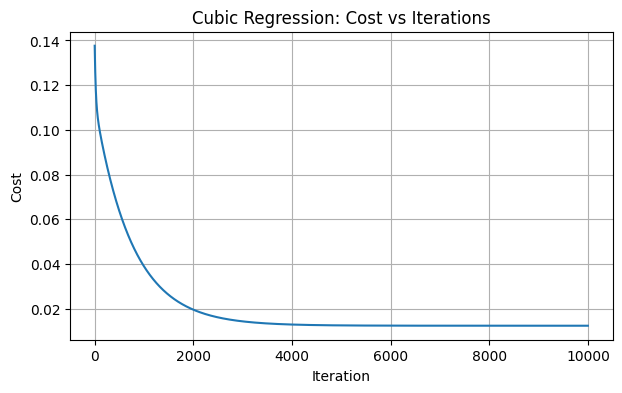

In [158]:
#Your code Here
#Plot the cost history against iteration number

# Plot the cubic cost history
plt.figure(figsize=(7, 4))
plt.plot(range(num_iterations_cubic), cost_history_cubic)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cubic Regression: Cost vs Iterations')
plt.grid(True)
plt.show()



#### Print Final Values of the Four θ's

In [159]:
#Your code Here
#Print the final learned values of theta (theta0, theta1, theta2, theta3)

# Print the final learned values of theta
print(f"theta0 = {theta_cubic[0]:.6f}")
print(f"theta1 = {theta_cubic[1]:.6f}")
print(f"theta2 = {theta_cubic[2]:.6f}")
print(f"theta3 = {theta_cubic[3]:.6f}")


theta0 = -0.110809
theta1 = -1.618743
theta2 = 0.115562
theta3 = 0.620874


### Run Predictions (Testing data)

In [160]:
# Your code Here
# Build test X the same way [1, test_x, test_x^2, test_x^3] (apply the SAME normalization used on training data)
# predictions = X_test @ theta
# _____DO NOT USE FOR LOOP_____

# Build the test cubic feature matrix using the SAME normalization as training
x_test_cubic = (x_test - cubic_mean) / cubic_std
X_test_cubic = np.column_stack((
    np.ones(x_test.shape[0]),
    x_test_cubic,
    x_test_cubic ** 2,
    x_test_cubic ** 3
))

y_pred_cubic = X_test_cubic @ theta_cubic
print("First 5 cubic predictions:")
print(y_pred_cubic[:5])

First 5 cubic predictions:
[-0.1868504   0.16945532  0.45523077  0.67545711  0.83511548]


### Mean Square Error

In [161]:
#Your code Here
#Using the cost function calculate the MSE of the model

# Calculate the cubic model MSE on the test data
mse_cubic = np.mean((y_pred_cubic - y_test) ** 2)/2
print(f"Cubic Regression Test MSE = {mse_cubic:.6f}")


Cubic Regression Test MSE = 0.025780


### Plot Data (Train and Test Data)

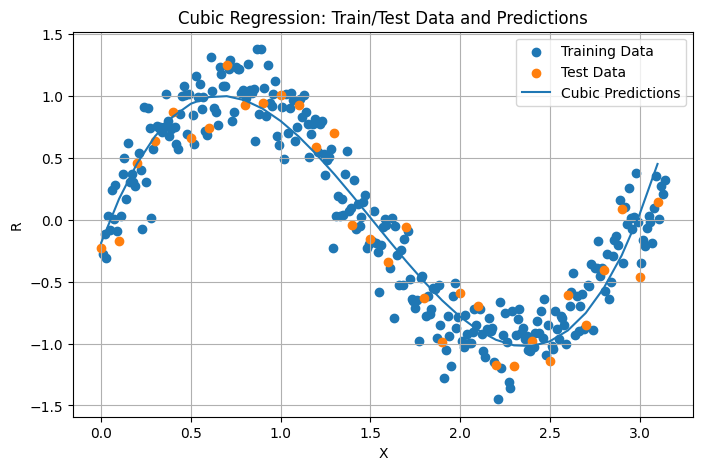

In [162]:
##Your code Here
#Plot the predicted values of y against the test_x

# Plot training data, test data, and cubic predictions
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, label='Training Data')
plt.scatter(x_test, y_test, label='Test Data')
order = np.argsort(x_test)
plt.plot(x_test[order], y_pred_cubic[order], label='Cubic Predictions')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Cubic Regression: Train/Test Data and Predictions')
plt.legend()
plt.grid(True)
plt.show()



### Now You Are Required To Fit Your 4, 5 and 6 Degree Models Step By Step Using Gradient Descent, As You Did Before

## Now Fit The 4 Degree Model

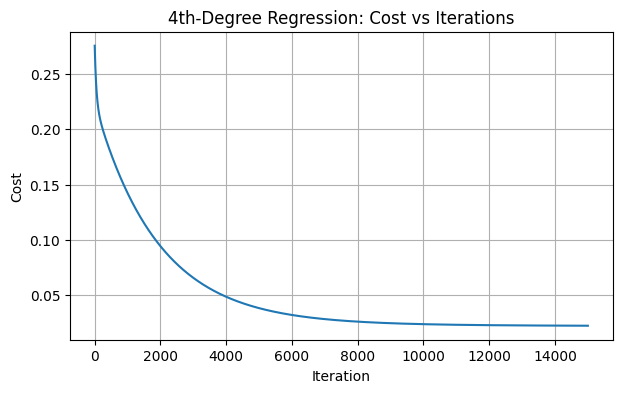

4th-degree theta: [-0.1605525  -1.5902313   0.30439036  0.60716156 -0.07635346]
4th-degree Test MSE = 0.024449


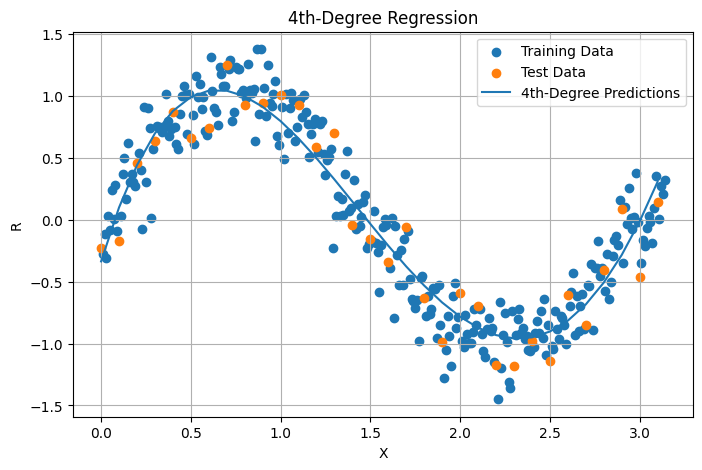

In [163]:
#Your code Here
#Build X = [1, x, x^2, x^3, x^4] (normalized), run Gradient Descent, predict, compute MSE, plot

# 4th-degree polynomial regression using Gradient Descent
deg4_mean = np.mean(x_train)
deg4_std = np.std(x_train)
z4_train = (x_train - deg4_mean) / deg4_std

X4 = np.column_stack([
    np.ones(x_train.shape[0]),
    z4_train,
    z4_train ** 2,
    z4_train ** 3,
    z4_train ** 4
])

theta4 = np.zeros(X4.shape[1])
alpha4 = 0.002
iterations4 = 15000
cost_history4 = []
m = len(y_train)

for i in range(iterations4):
    h4 = X4 @ theta4
    error4 = h4 - y_train
    cost4 = np.mean(error4 ** 2) / 2
    cost_history4.append(cost4)
    gradient4 = (X4.T @ error4) / m
    theta4 -= alpha4 * gradient4

z4_test = (x_test - deg4_mean) / deg4_std
X4_test = np.column_stack([
    np.ones(x_test.shape[0]),
    z4_test,
    z4_test ** 2,
    z4_test ** 3,
    z4_test ** 4
])
y_pred4 = X4_test @ theta4
mse4 = np.mean((y_pred4 - y_test) ** 2)/2

plt.figure(figsize=(7, 4))
plt.plot(range(iterations4), cost_history4)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('4th-Degree Regression: Cost vs Iterations')
plt.grid(True)
plt.show()

print("4th-degree theta:", theta4)
print(f"4th-degree Test MSE = {mse4:.6f}")

order = np.argsort(x_test)
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, label='Training Data')
plt.scatter(x_test, y_test, label='Test Data')
plt.plot(x_test[order], y_pred4[order], label='4th-Degree Predictions')
plt.xlabel('X')
plt.ylabel('R')
plt.title('4th-Degree Regression')
plt.legend()
plt.grid(True)
plt.show()



## Now Fit The 5 Degree Model

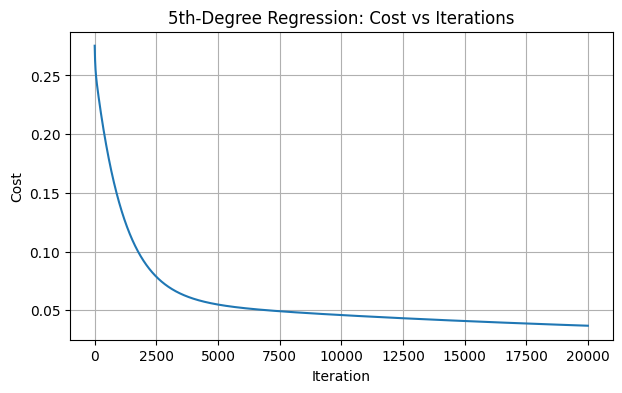

5th-degree theta: [-0.13930805 -1.12192866  0.24942032  0.00411503 -0.05704586  0.16280857]
5th-degree Test MSE = 0.038858


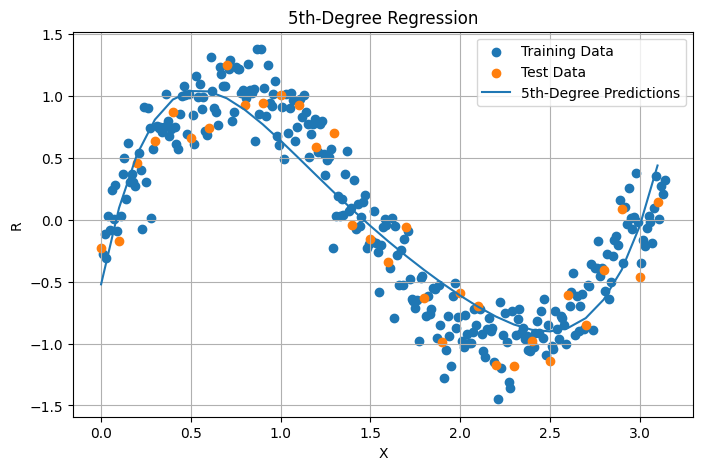

In [164]:
#Your code Here
#Build X = [1, x, x^2, x^3, x^4, x^5] (normalized), run Gradient Descent, predict, compute MSE, plot

# 5th-degree polynomial regression using Gradient Descent
deg5_mean = np.mean(x_train)
deg5_std = np.std(x_train)
z5_train = (x_train - deg5_mean) / deg5_std

X5 = np.column_stack([
    np.ones(x_train.shape[0]),
    z5_train,
    z5_train ** 2,
    z5_train ** 3,
    z5_train ** 4,
    z5_train ** 5
])

theta5 = np.zeros(X5.shape[1])
alpha5 = 0.001
iterations5 = 20000
cost_history5 = []
m = len(y_train)

for i in range(iterations5):
    h5 = X5 @ theta5
    error5 = h5 - y_train
    cost5 = np.mean(error5 ** 2) / 2
    cost_history5.append(cost5)
    gradient5 = (X5.T @ error5) / m
    theta5 -= alpha5 * gradient5

z5_test = (x_test - deg5_mean) / deg5_std
X5_test = np.column_stack([
    np.ones(x_test.shape[0]),
    z5_test,
    z5_test ** 2,
    z5_test ** 3,
    z5_test ** 4,
    z5_test ** 5
])
y_pred5 = X5_test @ theta5
mse5 = np.mean((y_pred5 - y_test) ** 2)/2

plt.figure(figsize=(7, 4))
plt.plot(range(iterations5), cost_history5)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('5th-Degree Regression: Cost vs Iterations')
plt.grid(True)
plt.show()

print("5th-degree theta:", theta5)
print(f"5th-degree Test MSE = {mse5:.6f}")

order = np.argsort(x_test)
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, label='Training Data')
plt.scatter(x_test, y_test, label='Test Data')
plt.plot(x_test[order], y_pred5[order], label='5th-Degree Predictions')
plt.xlabel('X')
plt.ylabel('R')
plt.title('5th-Degree Regression')
plt.legend()
plt.grid(True)
plt.show()



## Now Fit The 6 Degree Model

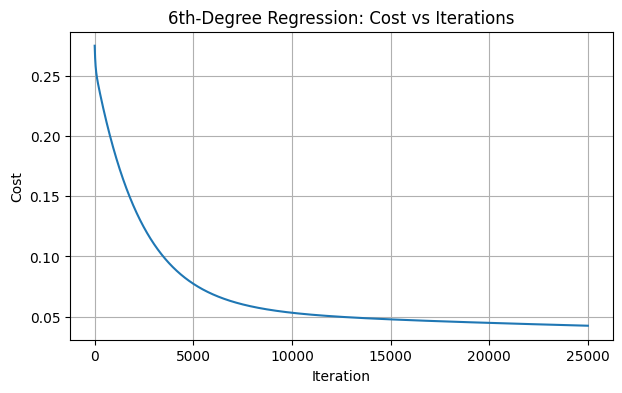

6th-degree theta: [-0.1367315  -0.99978161  0.13135622 -0.15512227  0.10611017  0.20642431
 -0.04622149]
6th-degree Test MSE = 0.046128


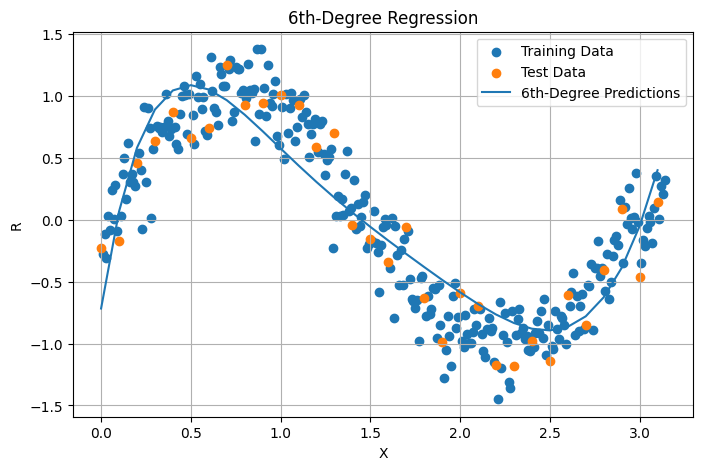

In [165]:
#Your code Here
#Build X = [1, x, x^2, ..., x^6] (normalized), run Gradient Descent, predict, compute MSE, plot

# 6th-degree polynomial regression using Gradient Descent
deg6_mean = np.mean(x_train)
deg6_std = np.std(x_train)
z6_train = (x_train - deg6_mean) / deg6_std

X6 = np.column_stack([
    np.ones(x_train.shape[0]),
    z6_train,
    z6_train ** 2,
    z6_train ** 3,
    z6_train ** 4,
    z6_train ** 5,
    z6_train ** 6
])

theta6 = np.zeros(X6.shape[1])
alpha6 = 0.0005
iterations6 = 25000
cost_history6 = []
m = len(y_train)

for i in range(iterations6):
    h6 = X6 @ theta6
    error6 = h6 - y_train
    cost6 = np.mean(error6 ** 2) / 2
    cost_history6.append(cost6)
    gradient6 = (X6.T @ error6) / m
    theta6 -= alpha6 * gradient6

z6_test = (x_test - deg6_mean) / deg6_std
X6_test = np.column_stack([
    np.ones(x_test.shape[0]),
    z6_test,
    z6_test ** 2,
    z6_test ** 3,
    z6_test ** 4,
    z6_test ** 5,
    z6_test ** 6
])
y_pred6 = X6_test @ theta6
mse6 = np.mean((y_pred6 - y_test) ** 2)/2

plt.figure(figsize=(7, 4))
plt.plot(range(iterations6), cost_history6)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('6th-Degree Regression: Cost vs Iterations')
plt.grid(True)
plt.show()

print("6th-degree theta:", theta6)
print(f"6th-degree Test MSE = {mse6:.6f}")

order = np.argsort(x_test)
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, label='Training Data')
plt.scatter(x_test, y_test, label='Test Data')
plt.plot(x_test[order], y_pred6[order], label='6th-Degree Predictions')
plt.xlabel('X')
plt.ylabel('R')
plt.title('6th-Degree Regression')
plt.legend()
plt.grid(True)
plt.show()



### Comment on the results by comparing all of your models (train/test MSE, convergence speed, overfitting/underfitting)

### Comment on the Results

The linear, quadratic, and cubic regression models were compared using their training and testing MSE, convergence speed, and their tendency to underfit or overfit. The linear model is the simplest model, so it converges relatively quickly and is less likely to overfit, but it may underfit the data if the relationship between X and R is nonlinear. The quadratic model is more flexible and can capture curvature in the data, so its training and testing MSE can be lower than the linear model when the data has a curved relationship. However, it requires more iterations to converge because it has additional parameters.

The cubic model provides even greater flexibility and can model more complex patterns. It can achieve a very low training MSE, but if its testing MSE is noticeably higher than its training MSE, this indicates overfitting. The convergence plots show how the cost decreases with iterations for each model; generally, the simpler linear model converges more quickly, while higher-degree models require more iterations to reach a stable cost.

Overall, increasing the polynomial degree reduces underfitting but increases the risk of overfitting and can make gradient descent slower to converge. Therefore, the difference between training and testing MSE is important when comparing the models. A model with a small gap between train and test MSE is showing better generalization, while a large gap suggests overfitting. The cost-vs-iteration plots provide additional evidence of whether each model has converged properly.
